# Edge sensitivity from the spectral distance

For the weighted combinatorial Laplacian, define
$H_{\Omega,\eta}=(L-\Omega I+i\eta I)^{-1}$. If $b_e=e_u-e_v$ for edge $e=(u,v)$, then

$$
S_e(\Omega,\eta)
:=d_{\Omega,\eta}^2(u,v)
=\lVert H_{\Omega,\eta}b_e\rVert_2^2
=\sum_{k=2}^{n}
\frac{|\psi_k(u)-\psi_k(v)|^2}
{(\lambda_k-\Omega)^2+\eta^2}.
$$

For weighted graphs, $I_e=w_eS_e$. Large values identify edges whose endpoints differ strongly in modes near $\Omega$.

Graph sizes and random seeds are fixed; the frequency centres are selected from each graph spectrum.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


SEED = 1
FIGURE_DIR = Path("figures") / "edge_sensitivity"

CLIQUE_SIZE = 7
GROUP_SIZE = 10
PARTITION_SIZE = 18

P_SAME_GROUP = 0.40
P_SAME_SUPERGROUP = 0.10
P_DIFFERENT_SUPERGROUP = 0.015
P_CROSS = 0.18
P_WITHIN = 0.015

SWEEP_POINTS = 60
PLOT_CAP = 3.0

CMAP = plt.cm.plasma
WINDOW_COLOURS = ["#0072B2", "#D55E00", "#009E73"]

np.random.seed(SEED)
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
})
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def laplacian_matrix(graph, nodes):
    return nx.laplacian_matrix(
        graph,
        nodelist=nodes,
        weight="weight",
    ).toarray()


def incidence_vector(nodes, u, v):
    index = {node: i for i, node in enumerate(nodes)}
    vector = np.zeros(len(nodes))
    vector[index[u]] = 1.0
    vector[index[v]] = -1.0
    return vector


def edge_scores(graph, omega, eta):
    nodes = list(graph.nodes())
    laplacian = laplacian_matrix(graph, nodes)
    # Same damped resolvent as in the README definition.
    resolvent = np.linalg.inv(
        laplacian - omega * np.eye(len(nodes))
        + 1j * eta * np.eye(len(nodes))
    )
    edges = [tuple(sorted((u, v))) for u, v in graph.edges()]

    sensitivities = []
    importances = []

    for u, v in edges:
        vector = incidence_vector(nodes, u, v)
        response = resolvent @ vector
        # This is d_{omega,eta}^2(u,v), not a separate edge metric.
        sensitivity = float(np.real(np.vdot(response, response)))
        weight = graph[u][v].get("weight", 1.0)
        sensitivities.append(sensitivity)
        importances.append(weight * sensitivity)

    return (
        edges,
        np.array(sensitivities),
        np.array(importances),
        resolvent,
        laplacian,
    )


def graph_spectrum(graph):
    laplacian = laplacian_matrix(graph, list(graph.nodes()))
    return np.linalg.eigvalsh(laplacian)


def relative_scores(scores):
    return np.asarray(scores) / np.mean(scores)

## Synthetic graphs

The barbell network contains a single bridge between dense groups. The hierarchical stochastic block model contains two nested grouping levels. The nearly bipartite graph is dominated by cross-partition edges.

In [2]:
# Barbell
barbell = nx.Graph()
barbell.add_edges_from(
    (u, v)
    for u in range(CLIQUE_SIZE)
    for v in range(u + 1, CLIQUE_SIZE)
)
barbell.add_edges_from(
    (u, v)
    for u in range(CLIQUE_SIZE, 2 * CLIQUE_SIZE)
    for v in range(u + 1, 2 * CLIQUE_SIZE)
)
bridge = (CLIQUE_SIZE - 1, CLIQUE_SIZE)
barbell.add_edge(*bridge)
barbell_classes = {
    tuple(sorted(edge)): (
        "bridge" if tuple(sorted(edge)) == bridge else "inside clique"
    )
    for edge in barbell.edges()
}


# Hierarchical SBM
sizes = [GROUP_SIZE] * 4
probabilities = np.full((4, 4), P_DIFFERENT_SUPERGROUP)
np.fill_diagonal(probabilities, P_SAME_GROUP)
probabilities[0, 1] = probabilities[1, 0] = P_SAME_SUPERGROUP
probabilities[2, 3] = probabilities[3, 2] = P_SAME_SUPERGROUP

hierarchical = nx.stochastic_block_model(sizes, probabilities, seed=2)
group = {
    node: data["block"]
    for node, data in hierarchical.nodes(data=True)
}
supergroup = {node: group[node] // 2 for node in hierarchical.nodes()}

hierarchical_classes = {}
for u, v in hierarchical.edges():
    edge = tuple(sorted((u, v)))
    if group[u] == group[v]:
        hierarchical_classes[edge] = "within subgroup"
    elif supergroup[u] == supergroup[v]:
        hierarchical_classes[edge] = "between subgroups"
    else:
        hierarchical_classes[edge] = "between supergroups"


# Nearly bipartite
rng = np.random.default_rng(3)
bipartite = nx.Graph()
bipartite.add_nodes_from(range(2 * PARTITION_SIZE))

for u in range(2 * PARTITION_SIZE):
    for v in range(u + 1, 2 * PARTITION_SIZE):
        cross = (u < PARTITION_SIZE) != (v < PARTITION_SIZE)
        probability = P_CROSS if cross else P_WITHIN
        if rng.random() < probability:
            bipartite.add_edge(u, v)

if not nx.is_connected(bipartite):
    largest_nodes = max(nx.connected_components(bipartite), key=len)
    bipartite = bipartite.subgraph(largest_nodes).copy()

bipartite_classes = {
    tuple(sorted((u, v))): (
        "cross-partition"
        if (u < PARTITION_SIZE) != (v < PARTITION_SIZE)
        else "within-partition"
    )
    for u, v in bipartite.edges()
}


graphs = {
    "Barbell": barbell,
    "Hierarchical SBM": hierarchical,
    "Nearly bipartite": bipartite,
}
class_maps = {
    "Barbell": barbell_classes,
    "Hierarchical SBM": hierarchical_classes,
    "Nearly bipartite": bipartite_classes,
}
class_orders = {
    "Barbell": ["bridge", "inside clique"],
    "Hierarchical SBM": [
        "within subgroup",
        "between subgroups",
        "between supergroups",
    ],
    "Nearly bipartite": ["cross-partition", "within-partition"],
}

For $0=\lambda_1\leq\lambda_2\leq\cdots\leq\lambda_n$, retain $|V|$, $|E|$, the first positive eigenvalue, and $\lambda_{\max}$.

In [3]:
spectra = {
    name: graph_spectrum(graph)
    for name, graph in graphs.items()
}

print(
    f"{'Graph':<20} {'Nodes':>6} {'Edges':>6} "
    f"{'Min positive':>14} {'Maximum':>12}"
)
for name, graph in graphs.items():
    positive = spectra[name][spectra[name] > 1e-10]
    print(
        f"{name:<20} {graph.number_of_nodes():6d} "
        f"{graph.number_of_edges():6d} "
        f"{positive[0]:14.6f} {positive[-1]:12.6f}"
    )

Graph                 Nodes  Edges   Min positive      Maximum
Barbell                  14     43       0.227998     8.772002
Hierarchical SBM         40    104       0.268961    11.376621
Nearly bipartite         35     59       0.415425     9.194086


## Spectral windows

Each graph uses $\eta=0.05\lambda_{\max}$. Three equally spaced centres span the positive spectrum from the first positive eigenvalue to $\lambda_{\max}$ and are labelled low, middle, and high.

In [4]:
windows = {}

for name, values in spectra.items():
    positive = values[values > 1e-10]
    windows[name] = {
        "eta": 0.05 * values[-1],
        "labels": ["low", "middle", "high"],
        "omegas": np.linspace(positive[0], positive[-1], 3),
    }

for name, choice in windows.items():
    values = ", ".join(
        f"{label}={omega:.6f}"
        for label, omega in zip(choice["labels"], choice["omegas"])
    )
    print(f"{name}: eta={choice['eta']:.6f}; {values}")

Barbell: eta=0.438600; low=0.227998, middle=4.500000, high=8.772002
Hierarchical SBM: eta=0.568831; low=0.268961, middle=5.822791, high=11.376621
Nearly bipartite: eta=0.459704; low=0.415425, middle=4.804756, high=9.194086


The points $(k,\lambda_k)$ give the ordered spectrum. Horizontal lines mark the selected values of $\Omega$.

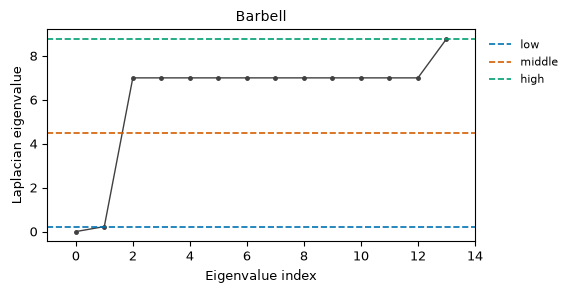

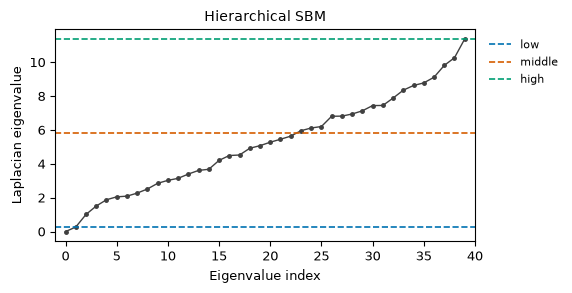

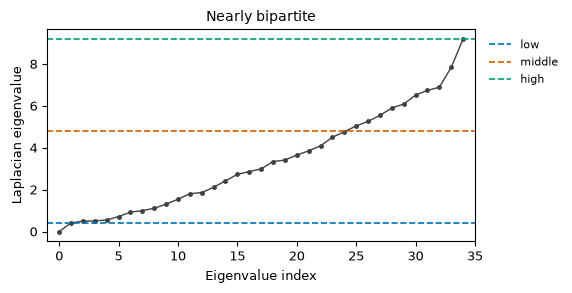

In [5]:
for name, values in spectra.items():
    fig, axis = plt.subplots(figsize=(5.8, 3.0))
    axis.plot(
        np.arange(len(values)),
        values,
        "o-",
        color="0.25",
        markersize=2.5,
        linewidth=1,
    )

    for label, omega, colour in zip(
        windows[name]["labels"],
        windows[name]["omegas"],
        WINDOW_COLOURS,
    ):
        axis.axhline(
            omega,
            color=colour,
            linestyle="--",
            linewidth=1.2,
            label=label,
        )

    axis.set(
        xlim=(-1, len(values)),
        xlabel="Eigenvalue index",
        ylabel="Laplacian eigenvalue",
        title=name,
    )
    axis.legend(
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
    )
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"{name.lower().replace(' ', '_')}_spectrum.png",
        dpi=150,
    )
    plt.show()

*Figures 1–3. Ordered Laplacian eigenvalues $\lambda_k$ for the three synthetic graphs. Dashed horizontal lines show the low, middle, and high centres.*

## Edge maps

At fixed $\Omega$, define the mean weighted edge importance

$$
\overline I(\Omega)
=\frac{1}{|E|}\sum_{f\in E}I_f(\Omega),
$$

and the relative edge sensitivity

$$
R_e(\Omega)
=\frac{I_e(\Omega)}{\overline I(\Omega)}.
$$

All three test graphs are unweighted, so $w_e=1$ and $I_e=S_e$. Therefore $R_e=1$ is the graph-wide mean sensitivity, $R_e>1$ is above the mean, and $R_e<1$ is below it. Edge colour represents $R_e(\Omega)$. Layout and colour limits are fixed within each graph. Values above three are clipped in the network maps.

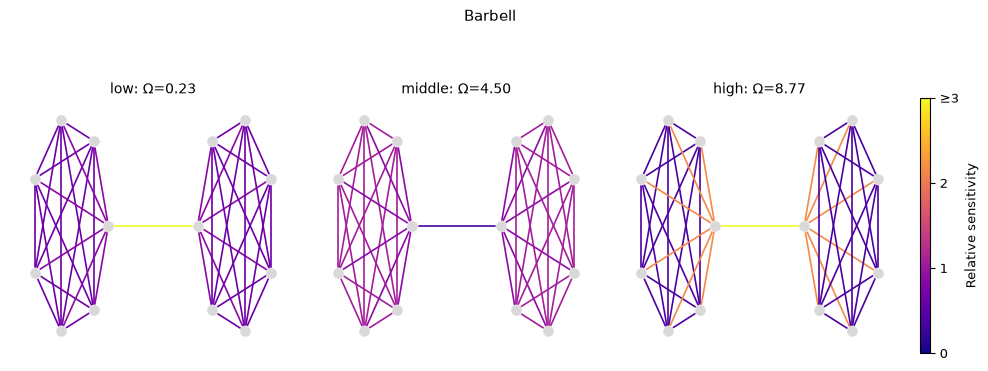

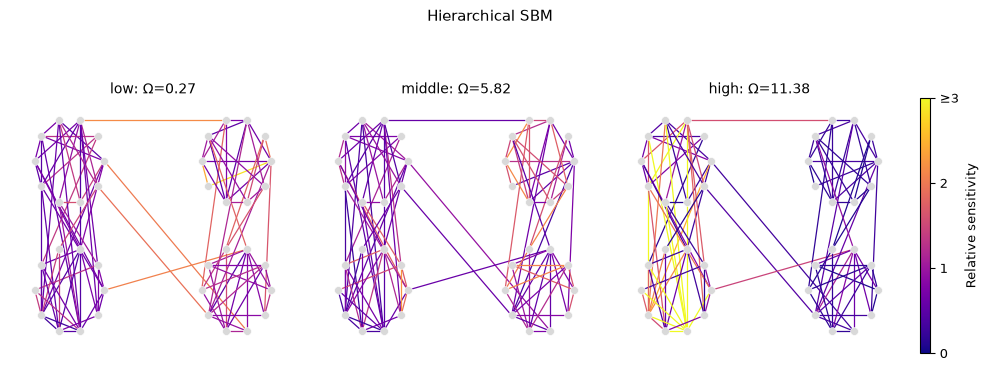

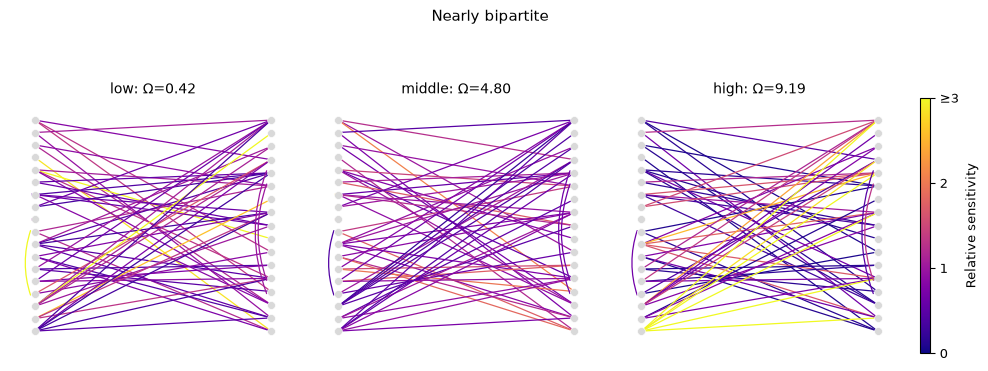

In [6]:
angles = np.linspace(0, 2 * np.pi, CLIQUE_SIZE, endpoint=False)
barbell_position = {}

left_order = [CLIQUE_SIZE - 1] + list(range(CLIQUE_SIZE - 1))
for node, angle in zip(left_order, angles):
    barbell_position[node] = (
        -1.4 + 0.65 * np.cos(angle),
        0.65 * np.sin(angle),
    )

for node, angle in zip(
    range(CLIQUE_SIZE, 2 * CLIQUE_SIZE),
    angles + np.pi,
):
    barbell_position[node] = (
        1.4 + 0.65 * np.cos(angle),
        0.65 * np.sin(angle),
    )


hierarchical_position = {}
centres = [
    (-1.2, 0.75),
    (-1.2, -0.75),
    (1.2, 0.75),
    (1.2, -0.75),
]
angles = np.linspace(0, 2 * np.pi, GROUP_SIZE, endpoint=False)

for block, centre in enumerate(centres):
    block_nodes = range(
        GROUP_SIZE * block,
        GROUP_SIZE * (block + 1),
    )
    for node, angle in zip(block_nodes, angles):
        hierarchical_position[node] = (
            centre[0] + 0.50 * np.cos(angle),
            centre[1] + 0.50 * np.sin(angle),
        )


left_nodes = sorted(node for node in bipartite if node < PARTITION_SIZE)
right_nodes = sorted(node for node in bipartite if node >= PARTITION_SIZE)
bipartite_position = {
    node: (-1.0, y)
    for node, y in zip(left_nodes, np.linspace(1, -1, len(left_nodes)))
}
bipartite_position.update({
    node: (1.0, y)
    for node, y in zip(right_nodes, np.linspace(1, -1, len(right_nodes)))
})


positions = {
    "Barbell": barbell_position,
    "Hierarchical SBM": hierarchical_position,
    "Nearly bipartite": bipartite_position,
}

for name, graph in graphs.items():
    score_sets = []
    for omega in windows[name]["omegas"]:
        edges, _, importance, _, _ = edge_scores(
            graph,
            omega,
            windows[name]["eta"],
        )
        score_sets.append(relative_scores(importance))

    fig = plt.figure(figsize=(10.0, 3.7))
    grid = fig.add_gridspec(
        1,
        4,
        width_ratios=[1, 1, 1, 0.035],
        wspace=0.08,
        left=0.02,
        right=0.94,
        bottom=0.05,
        top=0.74,
    )
    axes = [fig.add_subplot(grid[0, column]) for column in range(3)]
    colour_axis = fig.add_subplot(grid[0, 3])

    for axis, label, omega, values in zip(
        axes,
        windows[name]["labels"],
        windows[name]["omegas"],
        score_sets,
    ):
        edge_width = 1.2 if name == "Barbell" else 0.9
        node_size = 65 if name == "Barbell" else 32

        if name == "Nearly bipartite":
            within = np.array([
                class_maps[name][edge] == "within-partition"
                for edge in edges
            ])
            nx.draw_networkx_edges(
                graph,
                positions[name],
                edgelist=np.array(edges)[~within].tolist(),
                edge_color=values[~within],
                width=edge_width,
                edge_cmap=CMAP,
                edge_vmin=0,
                edge_vmax=PLOT_CAP,
                ax=axis,
            )
            nx.draw_networkx_edges(
                graph,
                positions[name],
                edgelist=np.array(edges)[within].tolist(),
                edge_color=values[within],
                width=edge_width,
                connectionstyle="arc3,rad=0.22",
                arrows=True,
                arrowstyle="-",
                edge_cmap=CMAP,
                edge_vmin=0,
                edge_vmax=PLOT_CAP,
                ax=axis,
            )
        else:
            nx.draw_networkx_edges(
                graph,
                positions[name],
                edgelist=edges,
                edge_color=values,
                width=edge_width,
                edge_cmap=CMAP,
                edge_vmin=0,
                edge_vmax=PLOT_CAP,
                ax=axis,
            )

        nx.draw_networkx_nodes(
            graph,
            positions[name],
            node_color="#d9d9d9",
            node_size=node_size,
            edgecolors="white",
            linewidths=0.4,
            ax=axis,
        )
        axis.set_title(label + rf": $\Omega$={omega:.2f}", pad=3)
        axis.set_axis_off()

    colour = plt.cm.ScalarMappable(
        cmap=CMAP,
        norm=plt.Normalize(vmin=0, vmax=PLOT_CAP),
    )
    colour_bar = fig.colorbar(colour, cax=colour_axis)
    colour_bar.set_ticks([0, 1, 2, 3])
    colour_bar.set_ticklabels(["0", "1", "2", "≥3"])
    colour_bar.set_label("Relative sensitivity", labelpad=4)
    fig.suptitle(name, fontsize=11, y=0.98)
    fig.savefig(
        FIGURE_DIR / f"{name.lower().replace(' ', '_')}_edge_scores.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

*Figures 4–6. Relative edge sensitivity $R_e(\Omega)=I_e(\Omega)/\overline I(\Omega)$ at the three selected window centres. Yellow edges have larger $R_e$; dark purple edges have smaller $R_e$.*

## Sweep by edge class

Let $E_c$ be the set of edges in structural class $c$. The quantity plotted for class $c$ is

$$
M_c(\Omega)
=\frac{1}{|E_c|}\sum_{e\in E_c}R_e(\Omega).
$$

The sweep covers $\lambda_2\leq\Omega\leq\lambda_{\max}$. The horizontal line at one is the graph-wide edge mean. A curve above one indicates that class $c$ has higher sensitivity than the average edge at that $\Omega$.

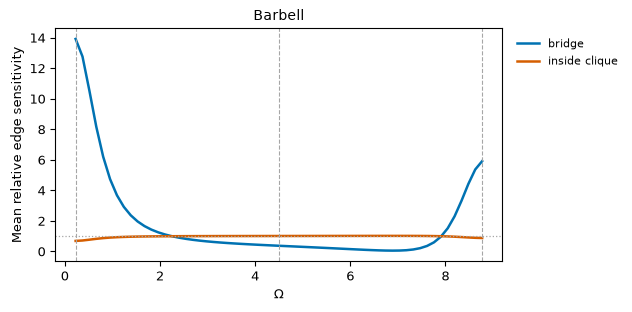

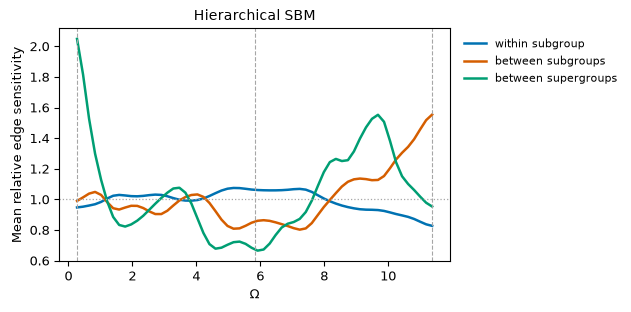

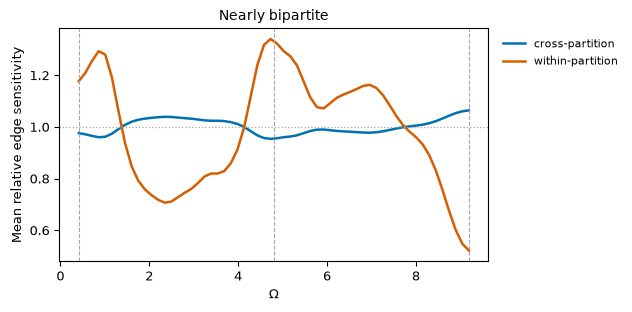

In [7]:
class_curves = {}

for name, graph in graphs.items():
    positive = spectra[name][spectra[name] > 1e-10]
    omega_grid = np.linspace(
        positive[0],
        positive[-1],
        SWEEP_POINTS,
    )
    curves = {
        edge_class: []
        for edge_class in class_orders[name]
    }

    for omega in omega_grid:
        edges, _, importance, _, _ = edge_scores(
            graph,
            omega,
            windows[name]["eta"],
        )
        relative = relative_scores(importance)

        for edge_class in class_orders[name]:
            mask = np.array([
                class_maps[name][edge] == edge_class
                for edge in edges
            ])
            curves[edge_class].append(np.mean(relative[mask]))

    class_curves[name] = {
        key: np.array(value)
        for key, value in curves.items()
    }

    fig, axis = plt.subplots(figsize=(6.4, 3.2))
    for edge_class, colour in zip(
        class_orders[name],
        WINDOW_COLOURS,
    ):
        axis.plot(
            omega_grid,
            curves[edge_class],
            color=colour,
            linewidth=1.8,
            label=edge_class,
        )

    axis.axhline(1.0, color="0.65", linestyle=":", linewidth=0.9)
    for omega in windows[name]["omegas"]:
        axis.axvline(
            omega,
            color="0.65",
            linestyle="--",
            linewidth=0.8,
        )

    axis.set(
        xlabel=r"$\Omega$",
        ylabel="Mean relative edge sensitivity",
        title=name,
    )
    axis.legend(
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
    )
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"{name.lower().replace(' ', '_')}_class_sweep.png",
        dpi=150,
    )
    plt.show()

*Figures 7–9. Class-mean relative sensitivity $M_c(\Omega)$ across the positive Laplacian spectrum. Vertical dashed lines mark the three selected window centres; the dotted horizontal line marks $M_c=1$.*

## Numerical checks

The predicted derivative norm is

$$
\frac{dH}{dw_e}=-Hb_eb_e^TH,
\qquad
S_e=\left\lVert\frac{dH}{dw_e}\right\rVert_F.
$$

For a small change $\varepsilon=10^{-6}$, compute

$$
S_e^{(\mathrm{FD})}
=\left\lVert
\frac{H(w_e+\varepsilon)-H(w_e)}{\varepsilon}
\right\rVert_F.
$$

Every hierarchical-SBM edge is evaluated at $\Omega_{\mathrm{middle}}$.

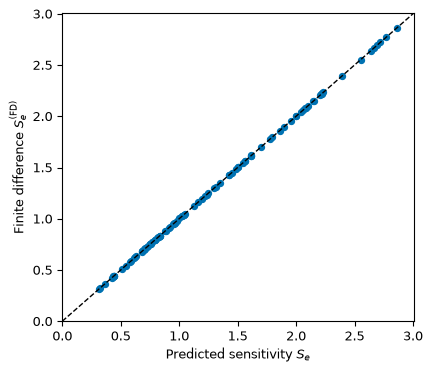

In [8]:
test_graph = hierarchical
test_omega = windows["Hierarchical SBM"]["omegas"][1]
test_eta = windows["Hierarchical SBM"]["eta"]
edges, sensitivities, _, resolvent, _ = edge_scores(
    test_graph,
    test_omega,
    test_eta,
)

epsilon = 1e-6
finite_differences = []

for u, v in edges:
    changed = test_graph.copy()
    changed[u][v]["weight"] = (
        changed[u][v].get("weight", 1.0) + epsilon
    )
    _, _, _, changed_resolvent, _ = edge_scores(
        changed,
        test_omega,
        test_eta,
    )
    finite_differences.append(
        np.linalg.norm(
            (changed_resolvent - resolvent) / epsilon,
            "fro",
        )
    )

finite_differences = np.array(finite_differences)
limit = 1.05 * max(sensitivities.max(), finite_differences.max())

fig, axis = plt.subplots(figsize=(4.4, 3.8))
axis.scatter(
    sensitivities,
    finite_differences,
    s=18,
    color="#0072B2",
)
axis.plot([0, limit], [0, limit], "k--", linewidth=1)
axis.set(
    xlim=(0, limit),
    ylim=(0, limit),
    xlabel=r"Predicted sensitivity $S_e$",
    ylabel=r"Finite difference $S_e^{(\mathrm{FD})}$",
)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "finite_difference_check.png", dpi=150)
plt.show()

*Figure 10. Predicted edge sensitivity $S_e$ against the finite-difference value $S_e^{(\mathrm{FD})}$. Each point is one hierarchical-SBM edge; the dashed line is $S_e^{(\mathrm{FD})}=S_e$.

Edge deletion tests the same resolvent response.

For $q_e=b_e^THb_e$, define the predicted change

$$
\widehat\Delta_e
=\frac{w_eS_e}{|1-w_eq_e|},
$$

and the directly measured change

$$
\Delta_e
=\lVert H_{\mathrm{deleted}}-H\rVert_F.
$$

Every edge is evaluated at the middle selected window of its graph.

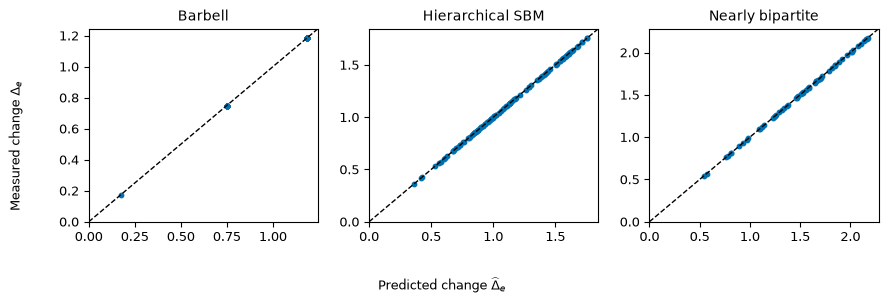

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.0))

for axis, (name, graph) in zip(axes, graphs.items()):
    omega = windows[name]["omegas"][1]
    eta = windows[name]["eta"]
    nodes = list(graph.nodes())
    edges, sensitivities, _, resolvent, _ = edge_scores(
        graph,
        omega,
        eta,
    )
    predicted = []
    measured = []

    for edge, sensitivity in zip(edges, sensitivities):
        u, v = edge
        vector = incidence_vector(nodes, u, v)
        weight = graph[u][v].get("weight", 1.0)
        q = vector @ resolvent @ vector
        predicted.append(
            weight * sensitivity / abs(1.0 - weight * q)
        )

        deleted = graph.copy()
        deleted.remove_edge(u, v)
        deleted_laplacian = laplacian_matrix(deleted, nodes)
        deleted_resolvent = np.linalg.inv(
            deleted_laplacian
            - omega * np.eye(len(nodes))
            + 1j * eta * np.eye(len(nodes))
        )
        measured.append(
            np.linalg.norm(deleted_resolvent - resolvent, "fro")
        )

    predicted = np.array(predicted)
    measured = np.array(measured)
    limit = 1.05 * max(predicted.max(), measured.max())
    axis.scatter(predicted, measured, s=10, color="#0072B2")
    axis.plot([0, limit], [0, limit], "k--", linewidth=1)
    axis.set(xlim=(0, limit), ylim=(0, limit), title=name)

fig.supxlabel(r"Predicted change $\widehat\Delta_e$", fontsize=9)
fig.supylabel(r"Measured change $\Delta_e$", fontsize=9)
fig.tight_layout(rect=(0.03, 0.03, 1, 1))
fig.savefig(FIGURE_DIR / "edge_deletion_check.png", dpi=150)
plt.show()

*Figure 11. Predicted deletion change $\widehat\Delta_e$ against measured change $\Delta_e$ for every edge. The dashed line is $\Delta_e=\widehat\Delta_e$.